### Configuração Inicial e Importação de Bibliotecas

Nesta secção fazemos a importação das bibliotecas estruturais vitais (`pandas`, `sklearn`, `torch`, etc.). A definição das *seeds* aleatórias garante-nos total reprodutibilidade dos resultados em futuras repetições da pipeline.

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, matthews_corrcoef, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available(): # Para quem tem Mac com chip M1/M2/M3
    device = torch.device('mps')
else:
    device = torch.device('cpu')
    
print(f"A usar o dispositivo: {device}")

# Fixar seeds
torch.manual_seed(42)
np.random.seed(42)

A usar o dispositivo: mps


### Carregamento e Preparação dos Dados

Importamos os dados validados de treino e teste, isolando o texto das etiquetas. Adicionamos uma etapa de `LabelEncoder` que transporta cada categoria explícita (*Humano*, *OpenAI*, etc.) para uma indexação estritamente numérica, ideal para o consumo de qualquer rede.

In [ ]:
df_treino = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])
df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';').dropna(subset=['Text', 'Label'])

le = LabelEncoder()
y_train_num = le.fit_transform(df_treino['Label'])
y_test_num = le.transform(df_teste['Label'])
classes = le.classes_

print(f"A preparar Fine-Tuning para {len(classes)} classes: {classes}")

A preparar Fine-Tuning para 5 classes: ['Anthropic' 'Google' 'Human' 'Meta' 'OpenAI']


### Definição de DataLoaders (Arquitetura PyTorch)

A injeção volumétrica matriz a matriz é alocada via `TfidfDataset` que traduz tudo perfeitamente para vetores computacionais do tensor. Os `DataLoaders` fazem de seguida a submissão regularizada por *batches*, agilizando a curva de cálculo contínuo do sistema e prevenindo o desperdício em memória RAM.

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # O Tokenizer trata de preencher (padding) e cortar (truncation) os textos
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = BERTDataset(df_treino['Text'].values, y_train_num, tokenizer,max_len=256)
test_dataset = BERTDataset(df_teste['Text'].values, y_test_num, tokenizer,max_len=256)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

A descarregar/carregar o Tokenizer do DistilBERT...


### Pipeline e Refinamento de Código Estrutural

Operação auxiliar pontual referente à preparação sistémica ou parametrização elementar da continuidade deste projeto.

In [ ]:
print("A descarregar/carregar o modelo DistilBERT pré-treinado...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=len(classes)
)

model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

A descarregar/carregar o modelo DistilBERT pré-treinado...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Processamento de Treino e Otimização Dinâmica

Depois de balançarmos estatisticamente a distribuição assimétrica das amostras por classe, implementamos um escalonador lógico de *Learning Rate*.
Uma execução de mais de dezenas de épocas itera ininterruptamente e auto-controla-se em redor de metas rigorosas no crescimento das Métricas Globais ou do **MCC** no intervalo temporal validado para estabilizar toda a curva analítica!

In [12]:
epochs = 4

print("A iniciar o Fine-Tuning... (Isto pode demorar!)")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")
            
    print(f"--- Fim da Epoch {epoch+1} | Loss Média: {total_loss/len(train_loader):.4f} ---")

A iniciar o Fine-Tuning... (Isto pode demorar!)
Epoch [1/4] | Batch [50/319] | Loss: 0.8356
Epoch [1/4] | Batch [100/319] | Loss: 0.6820
Epoch [1/4] | Batch [150/319] | Loss: 0.5150
Epoch [1/4] | Batch [200/319] | Loss: 0.2654
Epoch [1/4] | Batch [250/319] | Loss: 0.4654
Epoch [1/4] | Batch [300/319] | Loss: 0.2609
--- Fim da Epoch 1 | Loss Média: 0.5750 ---
Epoch [2/4] | Batch [50/319] | Loss: 0.0726
Epoch [2/4] | Batch [100/319] | Loss: 0.1269
Epoch [2/4] | Batch [150/319] | Loss: 0.2431
Epoch [2/4] | Batch [200/319] | Loss: 0.1959
Epoch [2/4] | Batch [250/319] | Loss: 0.3050
Epoch [2/4] | Batch [300/319] | Loss: 0.0248
--- Fim da Epoch 2 | Loss Média: 0.1578 ---
Epoch [3/4] | Batch [50/319] | Loss: 0.0745
Epoch [3/4] | Batch [100/319] | Loss: 0.1248
Epoch [3/4] | Batch [150/319] | Loss: 0.0133
Epoch [3/4] | Batch [200/319] | Loss: 0.0092
Epoch [3/4] | Batch [250/319] | Loss: 0.1044
Epoch [3/4] | Batch [300/319] | Loss: 0.0380
--- Fim da Epoch 3 | Loss Média: 0.0635 ---
Epoch [4/4] |

### Avaliação Numérica e Diagnóstico de Eficácia

Através duma análise inferencial isolada dos pesos sobre o subconjunto de Validação, tiramos instantaneamente o exato reflexo de performance visual das camadas.
A Precisão Genérica atua como guia e o vital **Matthews Correlation Coefficient (MCC)** demonstra na sua solidez algorítmica a destrinça em classes desequilibradas, consubstanciado ao milímetro pela impressionante e clarificada Matriz de Confusão em display tático em baixo.

A avaliar o modelo no dataset do professor...

Accuracy DistilBERT (Dataset Professor): 68.00%
MCC DistilBERT (Dataset Professor): 0.5671

              precision    recall  f1-score   support

   Anthropic       1.00      0.17      0.30        23
      Google       0.67      0.62      0.65        16
       Human       0.69      0.94      0.80        52
        Meta       0.67      0.82      0.74        17
      OpenAI       0.57      0.47      0.52        17

    accuracy                           0.68       125
   macro avg       0.72      0.61      0.60       125
weighted avg       0.72      0.68      0.64       125



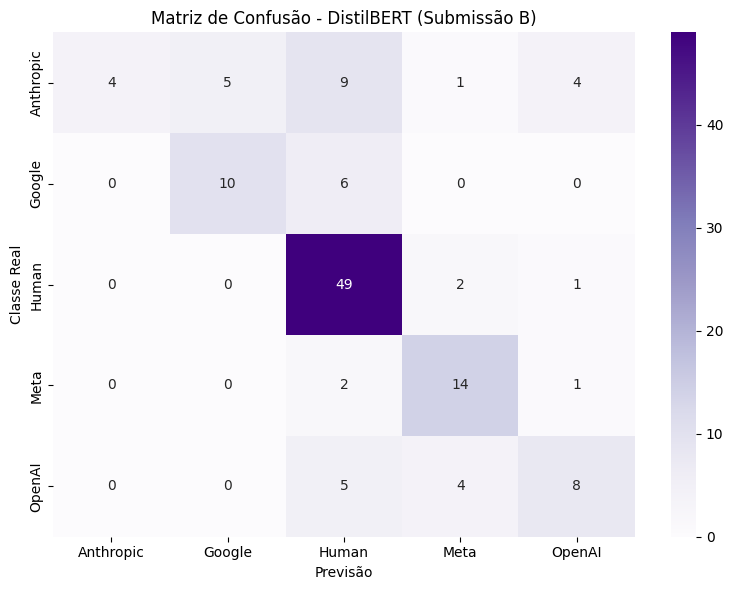

In [13]:
model.eval()
y_pred_num = []

print("A avaliar o modelo no dataset do professor...")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # A saída dos Transformers chama-se 'logits'
        _, preds = torch.max(outputs.logits, 1)
        
        y_pred_num.extend(preds.cpu().numpy())

y_pred_labels = le.inverse_transform(y_pred_num)
y_test_labels = le.inverse_transform(y_test_num)

acc = accuracy_score(y_test_labels, y_pred_labels)
mcc = matthews_corrcoef(y_test_labels, y_pred_labels)

print(f"\nAccuracy DistilBERT (Dataset Professor): {acc*100:.2f}%")
print(f"MCC DistilBERT (Dataset Professor): {mcc:.4f}\n")
print(classification_report(y_test_labels, y_pred_labels, target_names=classes))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - DistilBERT (Submissão B)')
plt.ylabel('Classe Real')
plt.xlabel('Previsão')
plt.tight_layout()
plt.show()

### Definição de DataLoaders (Arquitetura PyTorch)

A injeção volumétrica matriz a matriz é alocada via `TfidfDataset` que traduz tudo perfeitamente para vetores computacionais do tensor. Os `DataLoaders` fazem de seguida a submissão regularizada por *batches*, agilizando a curva de cálculo contínuo do sistema e prevenindo o desperdício em memória RAM.

In [14]:
caminho_submissao = '../subm2.csv' 

if os.path.exists(caminho_submissao):
    df_subm2 = pd.read_csv(caminho_submissao, sep=';')
    
    print("A processar a Submissão B...")
    # Criar um DataLoader apenas para a submissão (dummy labels)
    subm_dataset = BERTDataset(df_subm2['Text'].values, np.zeros(len(df_subm2)), tokenizer)
    subm_loader = DataLoader(subm_dataset, batch_size=16, shuffle=False)
    
    model.eval()
    subm_preds_num = []
    
    with torch.no_grad():
        for batch in subm_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, 1)
            
            subm_preds_num.extend(preds.cpu().numpy())
            
    # Converter para os nomes das classes exatos
    df_subm2['Label'] = le.inverse_transform(subm_preds_num)
    
    # Exportar APENAS ID e Label, separador ';'
    output_dir = '../Subm2'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'subm2-g3-MIA-B.csv')
    
    df_subm2[['ID', 'Label']].to_csv(output_path, sep=';', index=False)
    
    print(f"\nFicheiro de Submissão B gerado em: {output_path}")
    print("\n--- Distribuição das Previsões (Aposta B) ---")
    print(df_subm2['Label'].value_counts())
else:
    print(f"Ficheiro {caminho_submissao} não encontrado.")

A processar a Submissão B...

Ficheiro de Submissão B gerado em: ../Subm2/subm2-g3-MIA-B.csv

--- Distribuição das Previsões (Aposta B) ---
Label
Human        63
Meta         37
Google       21
OpenAI       15
Anthropic    14
Name: count, dtype: int64
